# Final Project: Geospatial Big Data Analysis

**submitted by:** Eliya Levin, 318163748

---

This program analyzes the following question upon a global dataset of power plants:

<div align="center">
  <i>How does the usage of renewable fuels for electricty production affect the level of development and power generation of countries?</i> 
</div>

Analysis and interpretation of results can be found in the adjoined `.docx` file named `Final assignment - project summary`.

---

**Data Sources:**
* `global_power_plant_database.csv` - Main analyzed dataset, extracted from the course Moodle page.
* `API_NY.GDP.MKTP.CD_DS2_en_csv_v2_234.csv` - GDP level data for each country, extracted from the [world bank data](https://data.worldbank.org/indicator/NY.GDP.MKTP.CD) (Last update - 13/07/2026).
* `Continents.shp` - Continent boundary shapefile, extracted from [Figshare website](https://figshare.com/articles/dataset/Continent_Polygons/12555170?file=23392280).

---

## Setup

### Libraries

In order to run program, ensure a correct code environment is set. For further information please refer to the adjoined `.YAML` file which lists all required dependencies.

In [1]:
# General
import time
import os

# Data handling
import math
import numpy as np
import pandas as pd
import geopandas as gpd
import json

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Geospatial statistics
import libpysal
import sklearn

### Environment
The program can be run on different folders, however it assumes a `data` folder exists in the same directory with all relevant data and an `outputs` folder to save all outputs created during the analysis. For cloned repositories from Github, no additional folder creation is required.

In [2]:
current_dir = os.getcwd() # directory path of the notebook
input_path = os.path.join(current_dir, r'data') # path to the input data folder
output_path = os.path.join(current_dir, r'outputs') # path to the output folder

## EDA: Exploratory Data Analysis

### Initial General Analysis & Cleaning

In [3]:
# Upload power plant csv file: Notice it's not a geographic layer yet
power_plants = pd.read_csv(input_path + r'\global_power_plant_database.csv')

In [4]:
# Inspect data types, columns and null-count
power_plants.info()

<class 'pandas.DataFrame'>
RangeIndex: 25648 entries, 0 to 25647
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   country                   25648 non-null  str    
 1   country_long              25648 non-null  str    
 2   name                      25628 non-null  str    
 3   gppd_idnr                 25648 non-null  str    
 4   capacity_mw               25648 non-null  float64
 5   latitude                  25648 non-null  float64
 6   longitude                 25648 non-null  float64
 7   fuel1                     25648 non-null  str    
 8   fuel2                     1670 non-null   str    
 9   fuel3                     295 non-null    str    
 10  fuel4                     107 non-null    str    
 11  commissioning_year        13926 non-null  float64
 12  owner                     17148 non-null  str    
 13  source                    25648 non-null  str    
 14  url              

In [5]:
# Remove irrelevant columns for analysis
power_plants.drop(columns=['name', 'gppd_idnr', 'owner', 'source', 'url', 'geolocation_source'], inplace=True)

relevant columns:
* `capacity_mw` - capacity in megawatts. How much energy the plant can produce in a given time.
* `country` - country code, enables to aggregate by each country.
* `fuel1` - main fuel used in the plant.
* `commissioning_year` - year in which the plant started working.
* `owner` - company which owns the plant (total of 8300)
* `generation_gwh_{year}` - total amount of electricity produced by the plant in a given year, measured in gigawatt-hours.

In [6]:
# Merge GDP values from World bank data (13/07/2026)

# Upload GDP csv file
# World bank data has metadata rows at the start, so we add a skiprows argument to avoid errors
gdp = pd.read_csv(input_path + r'\API_NY.GDP.MKTP.CD_DS2_en_csv_v2_234.csv', skiprows=4)

# Filter only relevant columns
gdp = gdp[['Country Code', '2013', '2014', '2015', '2016', '2017']]

# Update column names
gdp.rename(columns={
    'Country Code' : 'country',
    '2013' : 'GDP_2013',
    '2014' : 'GDP_2014',
    '2015' : 'GDP_2015',
    '2016' : 'GDP_2016',
    '2017' : 'GDP_2017',
}, inplace=True)

# Merge with power plant DataFrame
power_plants = power_plants.merge(gdp, how='left', on='country')

# Ensure correct merge
power_plants.head(n=10)

,country,country_long,capacity_mw,latitude,longitude,fuel1,fuel2,fuel3,fuel4,commissioning_year,...,generation_gwh_2013,generation_gwh_2014,generation_gwh_2015,generation_gwh_2016,estimated_generation_gwh,GDP_2013,GDP_2014,GDP_2015,GDP_2016,GDP_2017
0,AFG,Afghanistan,33.00,32.3220,65.1190,Hydro,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2.014642e+10,2.049713e+10,1.913422e+10,1.811657e+10,1.875346e+10
1,AFG,Afghanistan,66.00,34.5560,69.4787,Hydro,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2.014642e+10,2.049713e+10,1.913422e+10,1.811657e+10,1.875346e+10
2,AFG,Afghanistan,100.00,34.6410,69.7170,Hydro,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2.014642e+10,2.049713e+10,1.913422e+10,1.811657e+10,1.875346e+10
3,AFG,Afghanistan,11.55,34.4847,70.3633,Hydro,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2.014642e+10,2.049713e+10,1.913422e+10,1.811657e+10,1.875346e+10
4,AFG,Afghanistan,42.00,34.5638,69.1134,Gas,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2.014642e+10,2.049713e+10,1.913422e+10,1.811657e+10,1.875346e+10
5,AFG,Afghanistan,6.00,35.9416,68.7100,Hydro,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2.014642e+10,2.049713e+10,1.913422e+10,1.811657e+10,1.875346e+10
6,AFG,Afghanistan,22.00,34.5865,69.7757,Hydro,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2.014642e+10,2.049713e+10,1.913422e+10,1.811657e+10,1.875346e+10
7,ALB,Albania,27.00,39.9116,20.1047,Hydro,NaN,NaN,NaN,1965.0,...,NaN,NaN,NaN,NaN,89.132075,1.279699e+10,1.329632e+10,1.147017e+10,1.198867e+10,1.325827e+10
8,ALB,Albania,500.00,42.2514,20.0431,Hydro,NaN,NaN,NaN,1978.0,...,NaN,NaN,NaN,NaN,1650.593990,1.279699e+10,1.329632e+10,1.147017e+10,1.198867e+10,1.325827e+10
9,ALB,Albania,600.00,42.1033,19.8224,Hydro,NaN,NaN,NaN,1985.0,...,NaN,NaN,NaN,NaN,1980.712788,1.279699e+10,1.329632e+10,1.147017e+10,1.198867e+10,1.325827e+10


In [7]:
# Remove rows with missing GDP values - as this would be our response variable
# Dynamic creation of GDP columns ordered by year
gdp_cols = sorted([col for col in power_plants.columns if col.startswith('GDP_')]) 

# Remove rows
power_plants = power_plants.dropna(subset=gdp_cols)

# Print no. rows removed
after = len(power_plants) # current shape
print(f"Removed {25648 - after:,} rows") # original shape - 25648 rows

# Re-check null count for data
print()
power_plants.info()

Removed 87 rows

<class 'pandas.DataFrame'>
Index: 25561 entries, 0 to 25647
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   country                   25561 non-null  str    
 1   country_long              25561 non-null  str    
 2   capacity_mw               25561 non-null  float64
 3   latitude                  25561 non-null  float64
 4   longitude                 25561 non-null  float64
 5   fuel1                     25561 non-null  str    
 6   fuel2                     1670 non-null   str    
 7   fuel3                     295 non-null    str    
 8   fuel4                     107 non-null    str    
 9   commissioning_year        13891 non-null  float64
 10  year_of_capacity_data     16062 non-null  float64
 11  generation_gwh_2013       56 non-null     float64
 12  generation_gwh_2014       55 non-null     float64
 13  generation_gwh_2015       536 non-null    float64
 14  gener

Another valuable numeric value we can create is the Capacity factor ($C$). While an estimation of yearly energy production is calculated in Gigwatts per hour ($GWh$), a full working capcity is calculated in Megawatts ($MW$), resulting in the following conversion formula:
$$
GWh_{year}=\frac{MW \cdot 8,760}{1,000}
$$

with 8,760 being the yearly number of hours.

However, as power plants don't work in full capacity year-round (e.g. wind-powered plants in days with no wind), the capacity factor enables to fine-tune the formula as follows:

$$
GWh_{year}=\frac{MW \cdot 8,760 \cdot C}{1,000}
$$

In our dataset, we have both a $GWh_{year}$ estimation for many plants (`estimated_generation_gwh` column, $n=24,932$) and $MW$ (`capacity_mw` column, $n=25,648$), meaning we can calculate an estimate for each plant's capacity factor (including predictions for missing values using machine learning regression algorithms) to account for possible future changes in the capacity.

In [8]:
# Calculate capacity factor by reversing the formula above
power_plants['capacity_factor'] = (
    power_plants['estimated_generation_gwh'] * 1000
    / (power_plants['capacity_mw'] * 8760)
)

### Numerical Column Exploratory Analysis

In [9]:
# Describe base statistics for numeric columns
power_plants.describe().T

,count,mean,std,min,25%,50%,75%,max
capacity_mw,25561.0,1.563082e+02,4.507613e+02,1.000000e+00,4.000000e+00,1.460000e+01,8.000000e+01,8.868000e+03
latitude,25561.0,3.188325e+01,2.514277e+01,-5.378620e+01,2.847000e+01,4.076860e+01,4.821730e+01,7.129200e+01
longitude,25561.0,-2.778330e+01,6.692957e+01,-1.717124e+02,-8.199120e+01,-3.501470e+01,8.160100e+00,1.774833e+02
commissioning_year,13891.0,1.994051e+03,2.393877e+01,1.896000e+03,1.984000e+03,2.003000e+03,2.012000e+03,2.018000e+03
year_of_capacity_data,16062.0,2.016035e+03,1.261320e+00,2.000000e+03,2.016000e+03,2.016000e+03,2.016000e+03,2.018000e+03
generation_gwh_2013,56.0,2.518016e+03,7.274323e+03,1.000000e+01,1.393150e+02,4.390000e+02,1.356750e+03,5.083400e+04
generation_gwh_2014,55.0,4.033036e+03,4.743669e+03,7.000000e+00,6.375000e+02,2.196000e+03,5.818500e+03,2.161500e+04
generation_gwh_2015,536.0,1.411244e+03,3.719310e+03,0.000000e+00,2.615525e+01,2.710000e+02,1.342547e+03,5.954686e+04
generation_gwh_2016,8657.0,6.030753e+02,2.079092e+03,-7.686200e+02,3.331000e+00,2.372620e+01,2.179009e+02,3.237748e+04
estimated_generation_gwh,24853.0,6.964664e+02,2.447299e+03,0.000000e+00,6.710135e+00,3.456667e+01,2.528190e+02,4.714049e+04


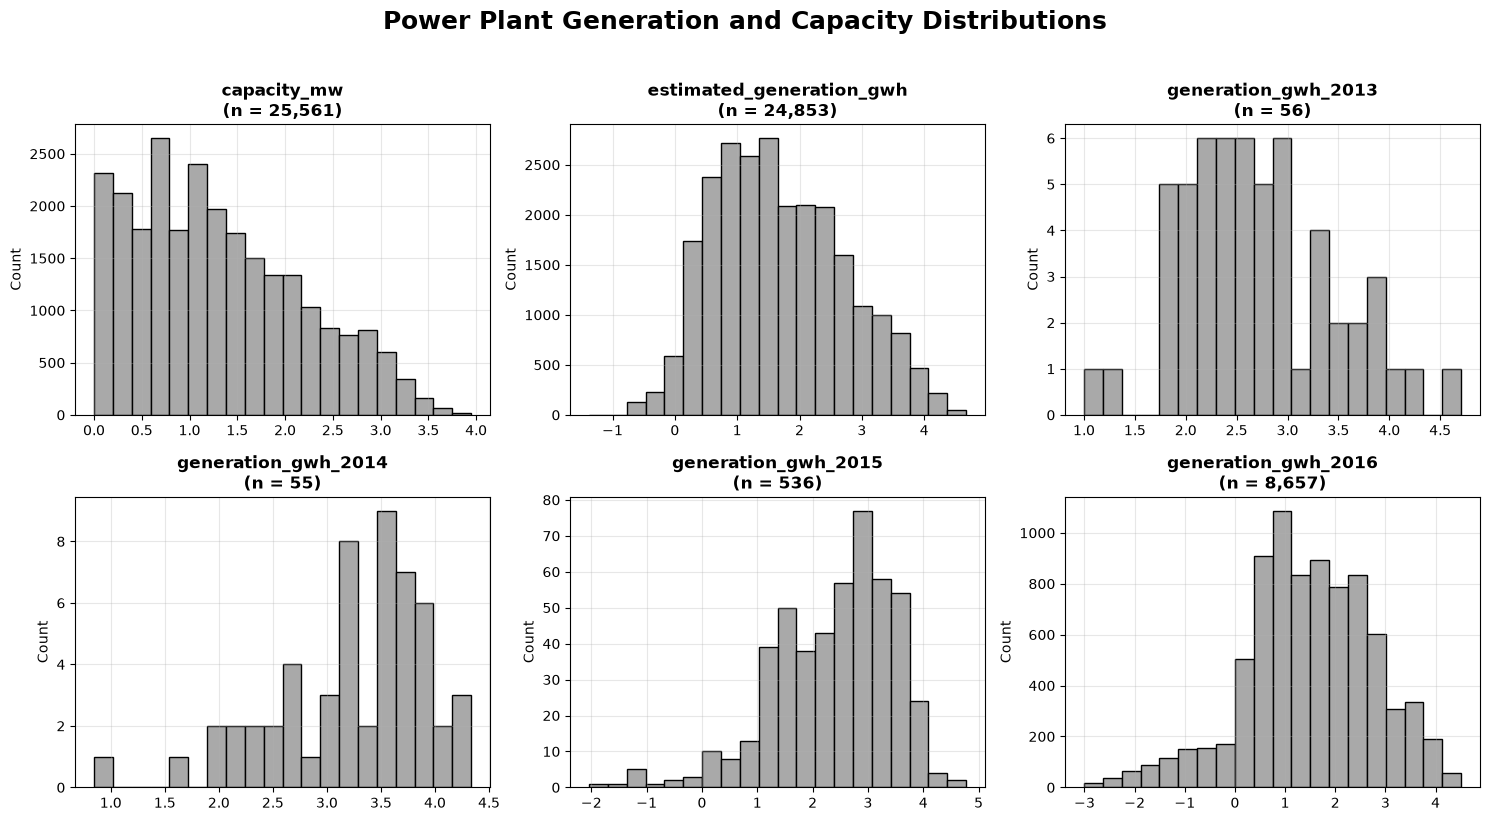

In [10]:
# Plot original numeric columns (capacity and electrical output) distributions
# List all columns distributions in requested plot order
plot_cols = ['capacity_mw', 'estimated_generation_gwh', 'generation_gwh_2013',
             'generation_gwh_2014', 'generation_gwh_2015', 'generation_gwh_2016']

# Define figure settings
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten() # Flatten axes list for loop ploting

# Plot all numeric variables distributions
for ax, col in zip(axes, plot_cols):

    data = power_plants[col].dropna() # Remove all nulls for plot
    log_data = np.log10(data[data > 0]) # Log transform data for better interpretability and magnitude comparisson

    # Transformed variable histogram
    ax.hist(
        log_data,
        bins=20,
        edgecolor='black',
        color='darkgrey'
    )

    # Design sub-plot
    ax.set_title(f'{col}\n(n = {len(data):,})', fontweight='bold') # Include feature number (non-null values in column)
    ax.set_ylabel('Count')
    ax.set_xlabel('')
    ax.grid(alpha=0.3)

# Add general plot title
fig.suptitle(
    'Power Plant Generation and Capacity Distributions',
    fontsize=18,
    fontweight='bold',
    y=1.02
)

# Save plot to outputs folder
plt.savefig(
    os.path.join(output_path, r'plots\Power plant generation and capacity distributions.png'), # Path for saved plot
    dpi=150,   # Required resolution in assignemnt
    bbox_inches='tight'
)

# Present plot
plt.tight_layout()
plt.show()

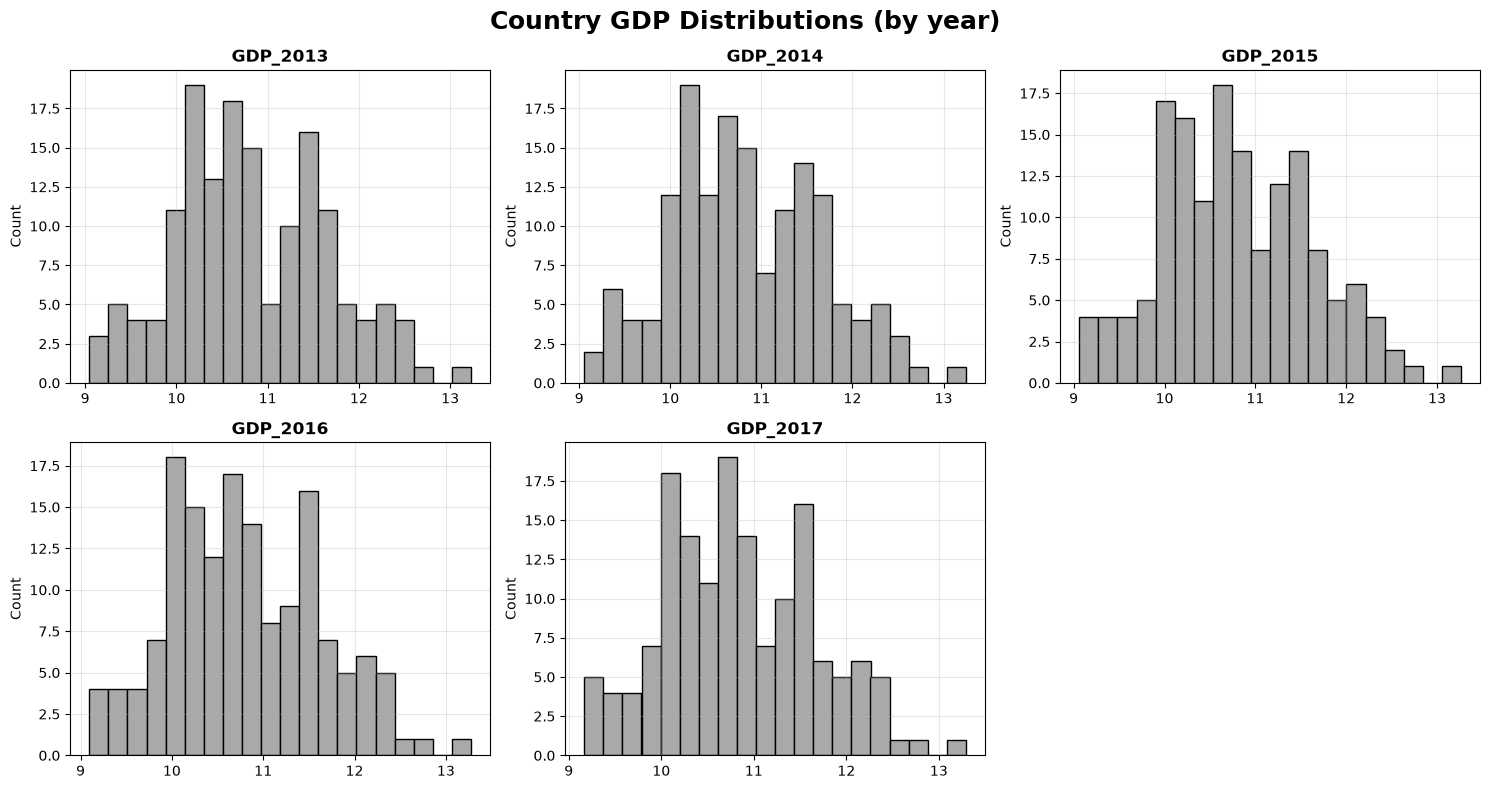

In [11]:
# Plot GDP distributions
# Grid size
n_cols = 3
n_rows = int(np.ceil(len(gdp_cols) / n_cols)) # Dynamic rows based on facet number

# Define figure settings
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4 * n_rows) # Dynamic figure size based on facet number
)
axes = axes.flatten()

# Plot all GDP distributions
for ax, col in zip(axes, gdp_cols):

    data = power_plants[col].dropna().drop_duplicates() # Remove missing values and duplicates (if exist)

    # Log-transform GDP values
    log_data = np.log10(data[data > 0]) # GDP tend to be highly skewed, therefore we apply log transform

    # Plot histogram
    ax.hist(
        log_data,
        bins=20,
        edgecolor='black',
        color='darkgrey'
    )

    # Design sub-plot labels
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Count')
    ax.set_xlabel('')
    ax.grid(alpha=0.3)

# Remove unused axes
for ax in axes[len(gdp_cols):]:
    fig.delaxes(ax)

# Add general title
fig.suptitle(
    'Country GDP Distributions (by year)',
    fontsize=18,
    fontweight='bold'
)

# Save plot to outputs folder
plt.savefig(
    os.path.join(output_path, r'plots\Country GDP distributions.png'), # Path for saved plot
    dpi=150,   # Required resolution in assignemnt
    bbox_inches='tight'
)

# Present plot
plt.tight_layout()
plt.show()

### Categorical Column Exploratory Analysis

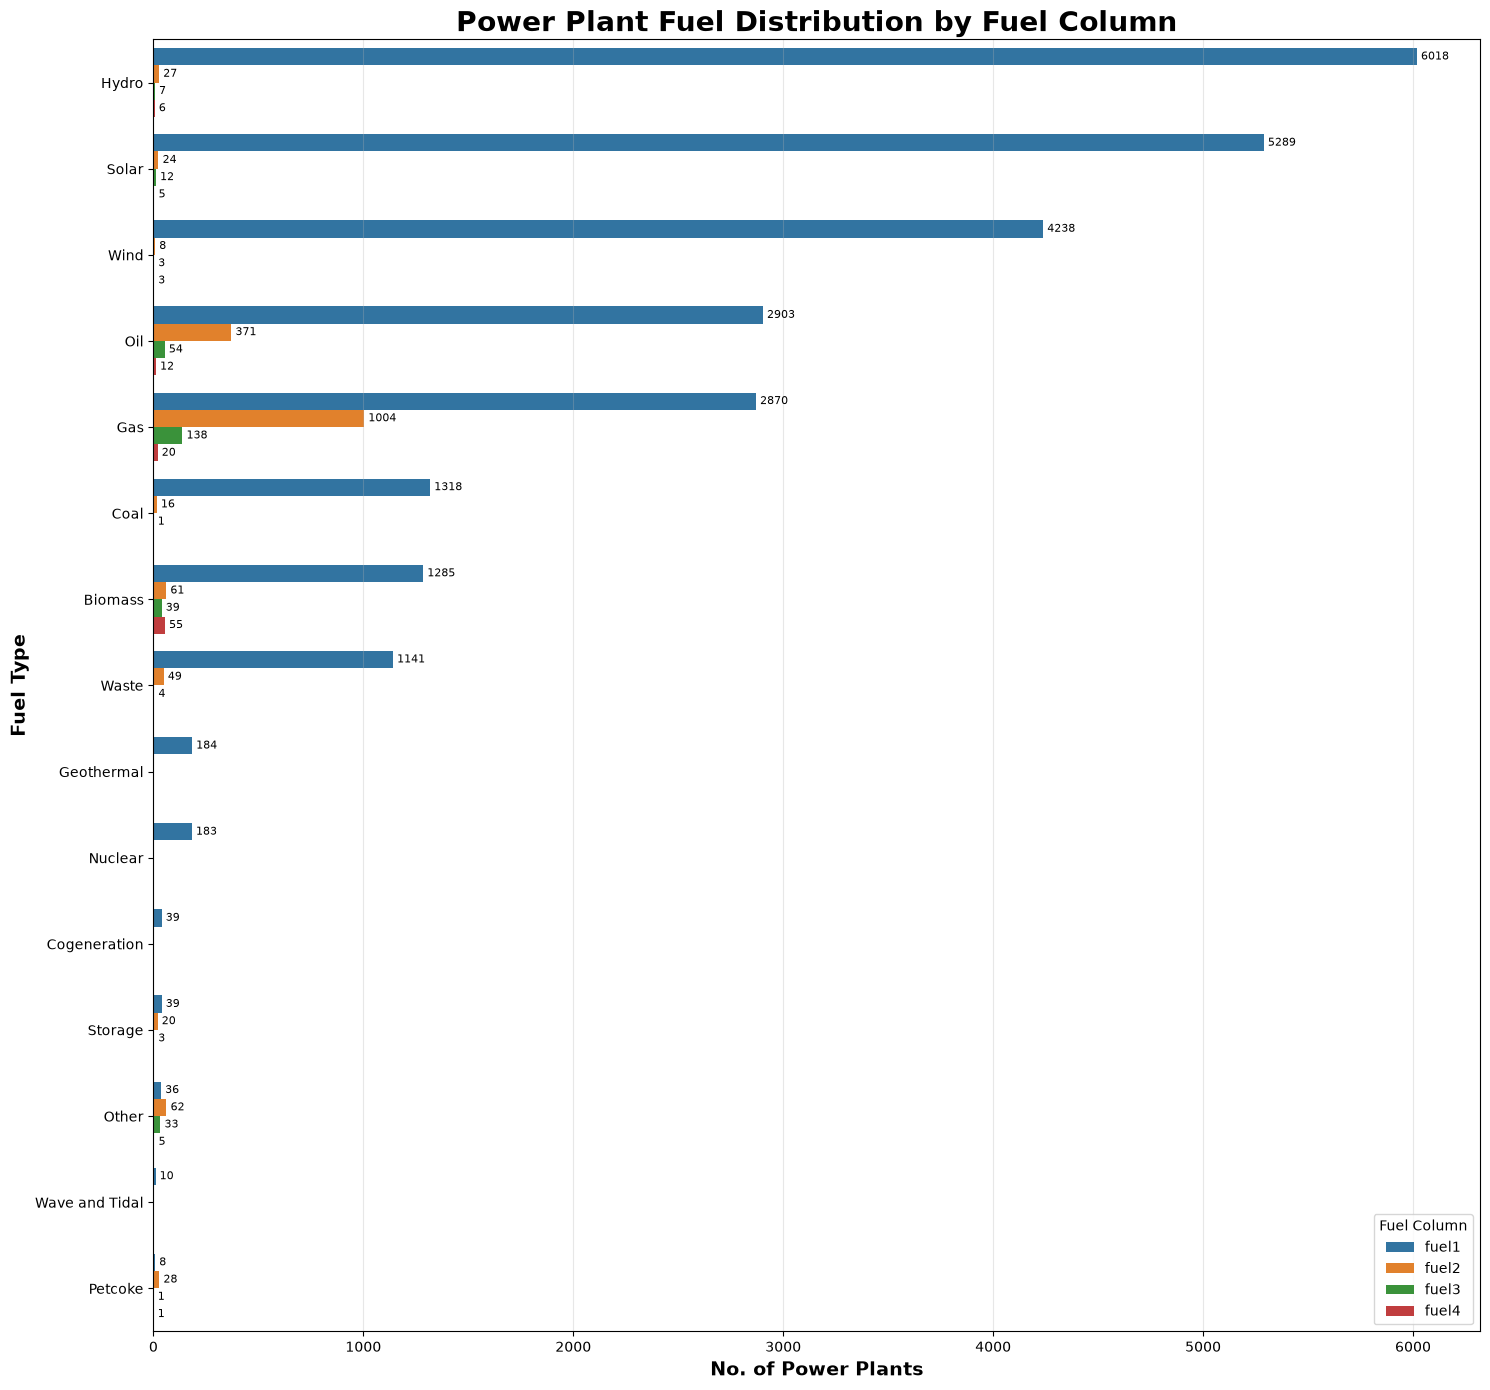

In [12]:
# Plot fuel types' (primary and others) distributions
# Define relevant plot columns
fuel_cols = ['fuel1', 'fuel2', 'fuel3', 'fuel4']

# Convert wide to long format for simpler ploting
fuel_long = (
    power_plants[fuel_cols]
    .melt(var_name='Fuel Column', value_name='Fuel Type')
    .dropna()
)

# Count values
fuel_counts = (
    fuel_long
    .groupby(['Fuel Column', 'Fuel Type']) # Count instances for each fuel type in each column
    .size()
    .reset_index(name='Count')
)

# Define order based on fuel1 - primary fuel source, most highly documented
fuel_order = (
    power_plants['fuel1']
    .value_counts()
    .index
)

# Define figure size
plt.figure(figsize=(15, 14))

# Plot all categories in descending order (based on fuel1)
ax = sns.barplot(
    data=fuel_counts,
    y='Fuel Type',
    x='Count',
    hue='Fuel Column', # Ensure different color for every column
    order=fuel_order
)

# Add labels - actual counts for interpretability
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%d',
        padding=3,
        fontsize=8
    )

# Add title and axis labels
ax.set_title('Power Plant Fuel Distribution by Fuel Column', fontsize=20, fontweight='bold')
ax.set_xlabel('No. of Power Plants', fontsize=14, fontweight='bold')
ax.set_ylabel('Fuel Type', fontsize=14, fontweight='bold')

# Add grid
ax.grid(axis='x', alpha=0.3)

# Save plot to outputs folder
plt.savefig(
    os.path.join(output_path, r'plots\Power plant fuel distributions.png'), # Path for saved plot
    dpi=150,   # Required resolution in assignemnt
    bbox_inches='tight'
)

# Present plot
plt.tight_layout()
plt.show()

### Temporal Distributions - Comissioning Year

In [14]:
# Arrange data for ploting
# Yearly data
year_counts = (
    power_plants['commissioning_year']
    .dropna()                           # Remove missing years
    .astype(int)                        # Ensure yearly format - integer and not float
    .value_counts()                     # Bin data
    .sort_index()                       # Sort in ascending year order
    .reset_index()
)

year_counts.columns = ['Year', 'Count'] # Define column names
years = year_counts['Year'] # Extract all years

# Decade data - aggregate year count by decade
decade_counts = (
    year_counts
    .assign(Decade=(year_counts['Year'] // 10) * 10) # Assign each year to it's decade
    .groupby('Decade', as_index=False)['Count']      # Group years by decade
    .sum()
)

decade_counts.columns = ['Decade', 'Count'] # Define column names

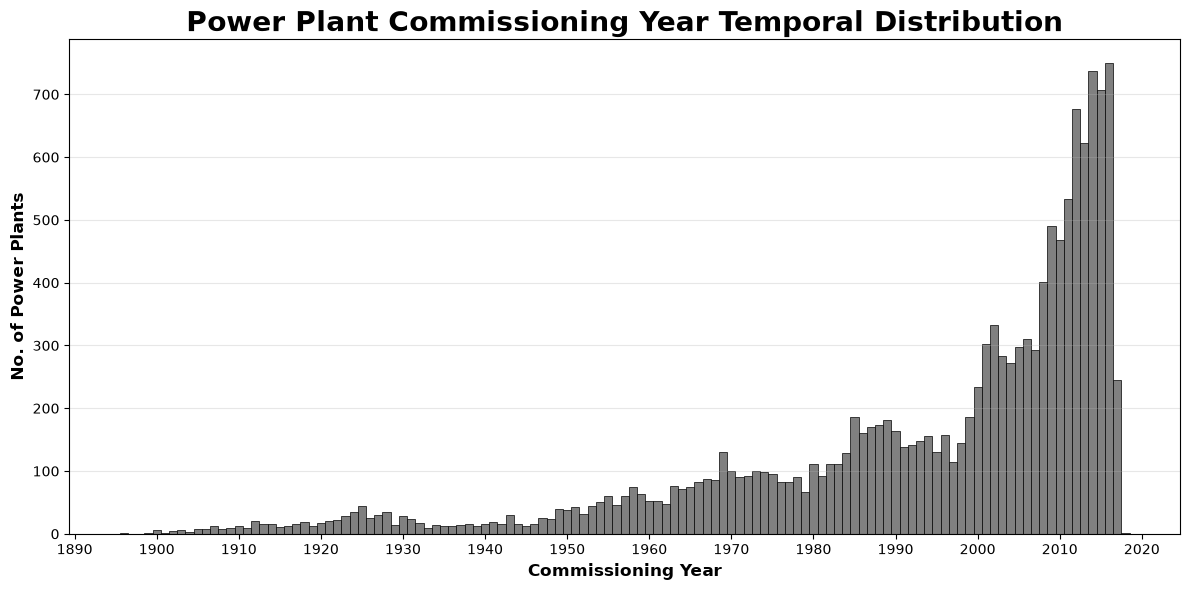

In [15]:
# Plot Temporal distribution: by year
# Define figure size
fig, ax = plt.subplots(figsize=(12, 6))

# Plot distribution
ax.bar(
    year_counts['Year'],
    year_counts['Count'],
    width=1,               # Each bar represents one year
    color='grey',
    edgecolor='black',
    linewidth=0.5
)

# Set ticks every decade for better interpretability
ax.set_xticks(
    np.arange(
        years.min() - years.min() % 10,
        years.max() + 10,
        10
    )
)

# Add title and axis labels
ax.set_title('Power Plant Commissioning Year Temporal Distribution', fontsize=20, fontweight='bold')
ax.set_xlabel('Commissioning Year', fontsize=12, fontweight='bold')
ax.set_ylabel('No. of Power Plants', fontsize=12, fontweight='bold')

# Design plot area
ax.tick_params(axis='x') # Remove irrelevant ticks
ax.grid(axis='y', alpha=0.3) # Add grid lines on y axis

# Save plot to outputs folder
plt.savefig(
    os.path.join(output_path, r'plots\Power plant commissioning year temporal distribution.png'), # Path for saved plot
    dpi=150,   # Required resolution in assignemnt
    bbox_inches='tight'
)

# Present plot
plt.tight_layout()
plt.show()

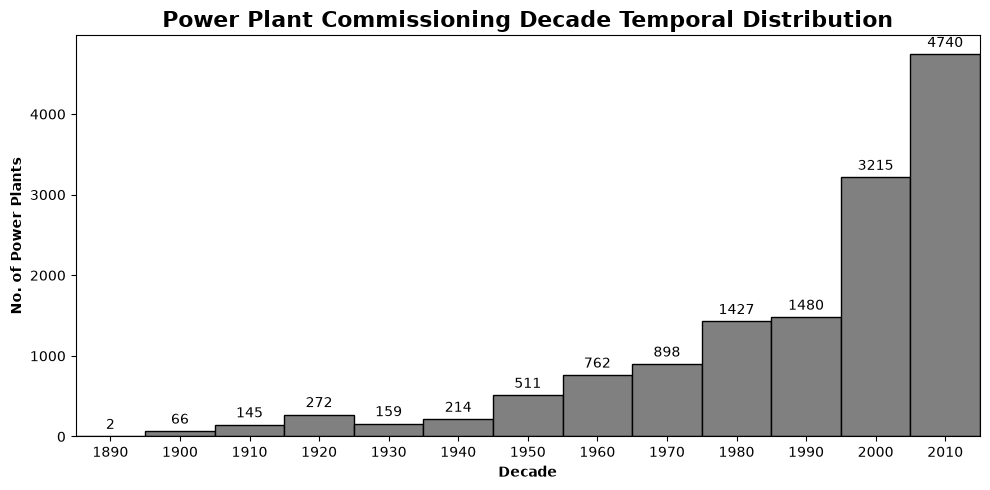

In [16]:
# Plot Temporal distribution: by decade
# Define figure size
plt.figure(figsize=(10, 5))

# Plot distribution
ax = sns.barplot(
    data=decade_counts,
    x='Decade',
    y='Count',
    width=1,     # Remove spaces between columns
    color='grey',
    edgecolor='black',
    linewidth=1
)

# Add counts above each bar
ax.bar_label(ax.containers[0], fmt='%d', padding=3)

# Add title and axis labels
ax.set_title('Power Plant Commissioning Decade Temporal Distribution', fontsize=16, fontweight='bold')
ax.set_xlabel('Decade', fontweight='bold')
ax.set_ylabel('No. of Power Plants', fontweight='bold')

# Save plot to outputs folder
plt.savefig(
    os.path.join(output_path, r'plots\Power plant commissioning decade temporal distribution.png'), # Path for saved plot
    dpi=150,   # Required resolution in assignemnt
    bbox_inches='tight'
)

# Present plot
plt.tight_layout()
plt.show()

### Spatial Distribution

In [17]:
# Convert to GeoDataFrame using longitude and latitude columns.
# Note: CRS is defined as EPSG 4326 (geographical world Datum WGS84), as it is a global dataset.
power_plants = gpd.GeoDataFrame(
    power_plants,
    geometry=gpd.points_from_xy(
        power_plants.longitude,
        power_plants.latitude
    ),
    crs="EPSG:4326"
)

In [18]:
continents = gpd.read_file(input_path + r'\Continents.shp') # Upload continent boundaries layer for spatial distribution plot
continents.to_crs(epsg=4326) if continents.crs != '4326' else None # Ensure CRS compatibility with power plant layer

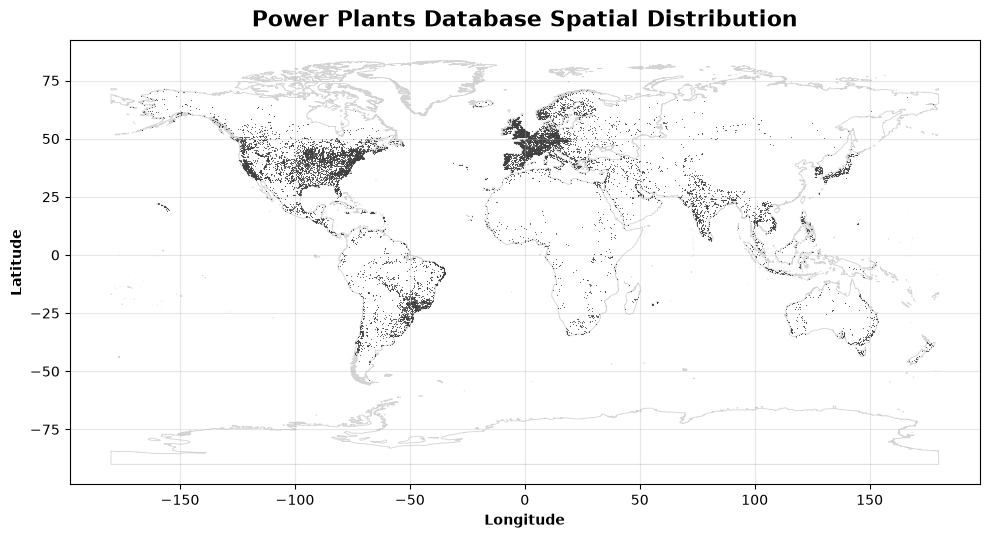

In [19]:
# Plot spatial distribution on map
# Define figure size
fig, ax = plt.subplots(figsize=(10, 6)) 

# Plot continent boundaries as basemap
continents.plot(
    ax=ax,
    color='white',
    edgecolor='lightgrey',
    linewidth=0.6
)

# Plot all power plant locations
power_plants.plot(
    ax=ax,
    markersize=0.4,
    color='black',
    edgecolor='grey',
    linewidth=0.1
)

# Add title and axis labels
ax.set_title('Power Plants Database Spatial Distribution', fontsize=16, fontweight='bold', pad=10)
ax.set_xlabel('Longitude', fontweight='bold')
ax.set_ylabel('Latitude', fontweight='bold')

# Add geographic gridlines
ax.grid(True, alpha=0.3) 

# Save plot to outputs folder
plt.savefig(
    os.path.join(output_path, r'plots\Power plant spatial distribution.png'), # Path for saved plot
    dpi=150,   # Required resolution in assignemnt
    bbox_inches='tight'
)

# Present plot
plt.tight_layout()
plt.show()

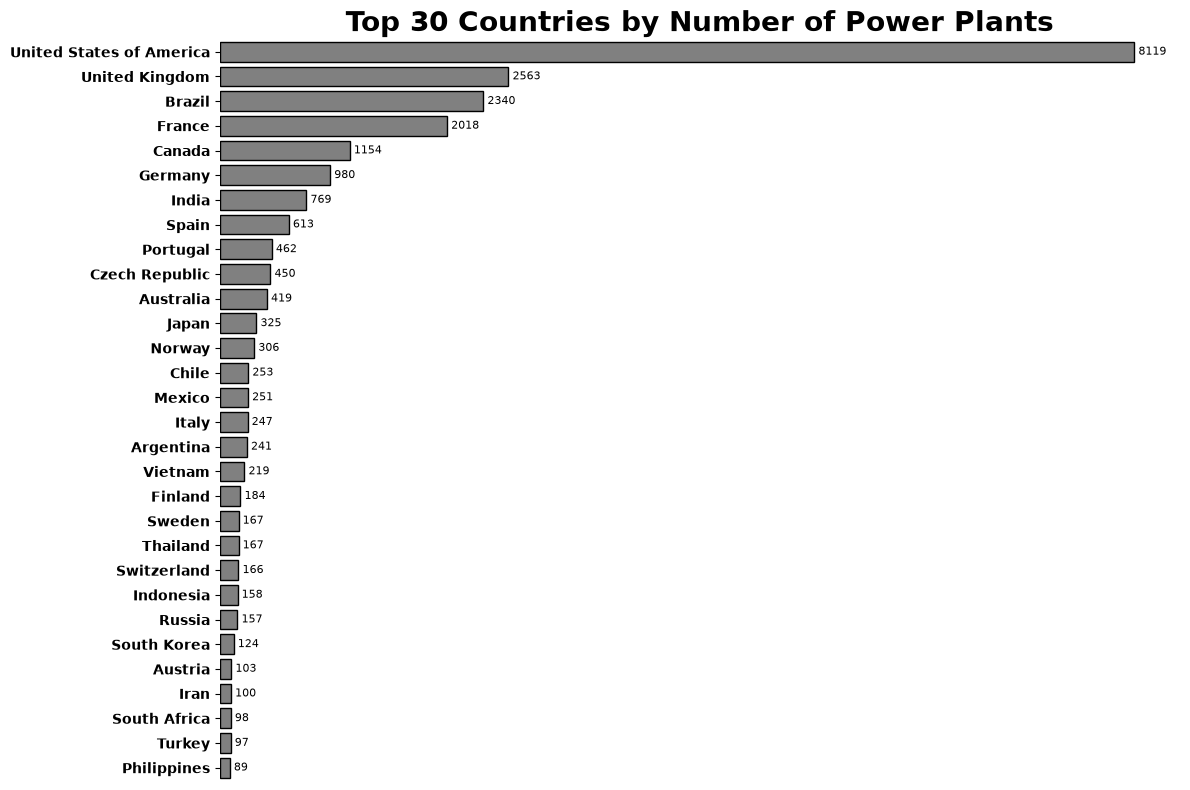

In [20]:
# Analysis by country
# Arrange data
country_counts = (
    power_plants['country_long']
    .value_counts()                 # Count plants per country
    .head(30)                       # Maintain only top 30 countries
    .reset_index()
)
country_counts.columns = ['Country', 'Count'] # Define column names

# Define figure size
plt.figure(figsize=(12, 8))

# Plot top 30 countries in descending order
ax = sns.barplot(
    data=country_counts,
    y='Country',
    x='Count',
    order=country_counts['Country'],
    color='grey',
    edgecolor='black'
)

# Add labels in each bar for inerpretability
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%d',
        padding=3,
        fontsize=8
    )

# Add title
ax.set_title('Top 30 Countries by Number of Power Plants', fontsize=20, fontweight='bold')

# Remove frame, axis labels and ticks
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

# Make y-axis labels bold
plt.setp(ax.get_yticklabels(), fontweight='bold')

# Save plot to outputs folder
plt.savefig(
    os.path.join(output_path, r'plots\Top 30 countries by number of power plants.png'), # Path for saved plot
    dpi=150,   # Required resolution in assignemnt
    bbox_inches='tight'
)

# Present plot
plt.tight_layout()
plt.show()

## Research Question Analysis

### Epicenter of renewable fuel usage
**Is there an epicenter for renewable fuel usage, and is there some spatial structure?**

* geographic clustering by column fuel1

### Correlation Analysis

#### GDP and Renewable Fuel Usage

use only fuel1
count number of fuels by country, analyze correlation

#### Electrical Capacity and Renewable Fuel Usage

use only fuel1
estimate generation using regression (ML)
average by country
analyze correlation